### **Create a Model who will create a Blog on the given Topic.**

In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from typing import TypedDict
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from pydantic import Field

load_dotenv()

True

In [3]:
llm_mode = ChatOpenAI(model='gpt-4-0613')

In [6]:

class BlogSchema(TypedDict):
    topic: str=Field(describe='This is the Topic on which the onliner should be created')
    outliner: str=Field(describe='This is the outliner on the given topic')
    blog: str=Field(describe='This is the Blog which is generated around outliner')

C:\Users\test\AppData\Local\Temp\ipykernel_17928\1514161862.py:2: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'describe'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  topic: str=Field(describe='This is the Topic on which the onliner should be created')
C:\Users\test\AppData\Local\Temp\ipykernel_17928\1514161862.py:3: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'describe'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  outliner: str=Field(describe='This is the outliner on the given topic')
C:\Users\test\AppData\Local\Temp\ipykernel_17928\1514161862.py:4: PydanticDeprecatedSince20: Using extra keyword arguments

In [10]:
def create_outliner(state:BlogSchema):
    topic = state['topic']

    message = [
        SystemMessage(content='You are a Helpful Assistant, who can create Ouliners on the given Topic.'),
        HumanMessage(content=f'''
create a outliner on the given topic: Topic= {topic}
''')
    ]

    outliner = llm_mode.invoke(message).content

    return {'outliner':outliner}

In [12]:
def create_blog(state: BlogSchema):
    topic = state['topic']
    outliner = state['outliner']

    message = [
        SystemMessage(content='You are a helpful Assistant, Who can build a Blog using Topic and Outliners'),
        HumanMessage(content=f'''
Create a Funny and Interesting blog on the given topic: {topic}, use all the possible memes and recent jockes to make the blog funny and attractive for the readers, for genz people. On the below outliners\n
Outliners: {outliner}
''')
    ]

    blog = llm_mode.invoke(message).content
    return {'blog':blog}

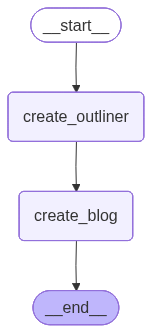

In [14]:
graph = StateGraph(BlogSchema)

## add node
graph.add_node('create_outliner', create_outliner)
graph.add_node('create_blog', create_blog)

## add edges
graph.add_edge(START,'create_outliner')
graph.add_edge('create_outliner', 'create_blog')
graph.add_edge('create_blog', END)

## graph compile
final_graph = graph.compile()

final_graph

In [15]:
initial_state = {
    'topic': 'Indian Railway',
    'outliner':'',
    'blog':''
}

response = final_graph.invoke(initial_state)
response

{'topic': 'Indian Railway',
 'outliner': 'I. Introduction \n   A. Brief Overview of the Indian Railways \n   B. Importance of Railways in India \n\nII. History of Indian Railways\n   A. First Railway routes \n   B. British influence and establishment of train services\n   C. Post-Independence development \n   \nIII. Organization of Indian Railways  \n   A. Ministry of Railways \n   B. The Railway Board \n   C. Divisions and Zones\n\nIV. Infrastructure\n   A. Tracks and Gauges\n   B. Railway Stations\n   C. Trains and types\n   D. Modernization efforts\n    \nV. Services \n   A. Passenger Services\n      1. Special Trains\n      2. Luxury Trains\n   B. Freight Services\n   C. Online Services such as ticket booking through IRCTC \n\nVI. Indian Railways and the Economy \n   A. Contribution to the Indian Economy \n   B. Employment Generation\n\nVII. Challenges faced by Indian Railways \n   A. Safety Concerns \n   B. Management Issues\n   C. Financial Constraints \n\nVIII. Future Prospects 